# sourcing the data

In [1]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import math
import json 

from plots.utils import load_sledge_data, prepare_step_data
plt.style.use('./plots/latex_style.mplstyle')

RESULTS_DIR = Path("../benchmarks/results")

RESULTS_DIR_ALT = Path("../results")


FIGURES_PATH = RESULTS_DIR_ALT / 'plots'
os.makedirs(FIGURES_PATH, exist_ok=True)

alive_pb = pd.read_csv(f'{RESULTS_DIR}/solver/Alive_parabit/results.csv')
hydra_pb = pd.read_csv(f'{RESULTS_DIR}/solver/Hydra_parabit/results.csv')
rover_pb = pd.read_csv(f'{RESULTS_DIR}/solver/ROVER_parabit/results.csv')
cadence_pb = pd.read_csv(f'{RESULTS_DIR}/solver/Cadence_parabit/results.csv')


alive_pbv = pd.read_csv(f'{RESULTS_DIR}/solver/alive_smt2/results.csv')
hydra_pbv = pd.read_csv(f'{RESULTS_DIR}/solver/hydra_smt2/results.csv')

rover_mirabelle = {}

rover_mirabelle["lemma"] = load_sledge_data(RESULTS_DIR_ALT / "mirabelle" / "lemma" / "ROVER" / "parsed.json")
rover_mirabelle["nolemma"] = load_sledge_data(RESULTS_DIR_ALT / "mirabelle" / "nolemma" / "ROVER" / "parsed.json")

alive_pb

,file,status,time_taken,max_memory_mb,timed_out,last_err_line,problem_name,verified,theorem_size
0,AndOrXor_2429_values_0.bwlang,SUCCESS,0.012450,1.875000,False,[2026-01-28T21:08:59Z INFO parabit] Iteration...,AndOrXor_2429_values_0,NaN,NaN
1,AndOrXor_2486_values_0.bwlang,SUCCESS,0.022351,8.675781,False,[2026-01-28T21:08:59Z INFO parabit] Iteration...,AndOrXor_2486_values_0,NaN,NaN
2,AndOrXor_1388_values_0.bwlang,FAILED,0.927954,739.769531,False,note: run with `RUST_BACKTRACE=1` environment ...,AndOrXor_1388_values_0,NaN,NaN
3,AndOrXor_1346b_values_0.bwlang,SUCCESS,0.012288,1.625000,False,[2026-01-28T21:09:00Z INFO parabit] Iteration...,AndOrXor_1346b_values_0,NaN,NaN
4,AddSub_1164_values_0.bwlang,SUCCESS,0.012223,1.625000,False,[2026-01-28T21:09:00Z INFO parabit] Iteration...,AddSub_1164_values_0,NaN,NaN
...,...,...,...,...,...,...,...,...,...
57,AndOrXor_144_values_0.bwlang,SUCCESS,0.012174,1.625000,False,[2026-01-28T21:11:30Z INFO parabit] Iteration...,AndOrXor_144_values_0,NaN,NaN
58,AndOrXor_1241_values_0.bwlang,SUCCESS,0.012209,1.625000,False,[2026-01-28T21:11:30Z INFO parabit] Iteration...,AndOrXor_1241_values_0,NaN,NaN
59,AddSub_1624_values_0.bwlang,SUCCESS,0.093240,24.621094,False,[2026-01-28T21:11:30Z INFO parabit] Iteration...,AddSub_1624_values_0,NaN,NaN
60,AddSub_1202_values_0.bwlang,SUCCESS,0.022455,9.363281,False,[2026-01-28T21:11:30Z INFO parabit] Iteration...,AddSub_1202_values_0,NaN,NaN


In [2]:
def plot_cactus(ax, dataframe, timeout = None, pltopts = None):
    num_problems = len(dataframe)
    
    ax.axhline(num_problems, label=f'Number of problems: {num_problems}',color='black', linestyle='dotted')
    if timeout:
        ax.axvline(timeout, label=f'Timeout: {timeout/1000:.3g} Seconds', color='grey', linestyle='--')

    for name, values in dataframe.items():
        solved = values.dropna()
        x, y = prepare_step_data(solved.to_list())
        
        if timeout and x[-1] < timeout:
            y.append(y[-1])
            x.append(timeout)
        
        line_opts = pltopts.get(name, {}) if pltopts else {}
        
        ax.plot(x, y, drawstyle="steps-post", label=f"{name}: {len(solved)} (${100*len(solved)/num_problems:.0f}\\%$) ", **line_opts)

    ax.set_xlabel('Runtime (ms)')
    ax.set_ylabel('Number of solved problems')
    ax.set_xscale('log')

def plot_survival(ax, dataframe, timeout = None, pltopts = None):
    num_problems = len(dataframe)
    
    ax.axvline(num_problems, label=f'Number of problems: {num_problems}',color='blue')
    if timeout:
        ax.axhline(timeout, label=f'Timeout: {timeout/1000:.3g} Seconds', color='grey', linestyle='--')

    for name, values in dataframe.items():
        solved = values.dropna()
        y, x = prepare_step_data(solved.to_list())
        
        if timeout and x[-1] < num_problems:
            x.append(x[-1])
            y.append(timeout)
        
        line_opts = pltopts.get(name, {}) if pltopts else {}
        
        ax.plot(x, y, drawstyle="steps-post", label=f"{name}: {len(solved)} (${100*len(solved)/num_problems:.0f}\\%$) ", **line_opts)

    ax.set_ylabel('Runtime (ms)')
    ax.set_xlabel('Number of solved problems')
    ax.set_yscale('log')

def combine_results(x):
    vals_as_list = x.dropna().to_list()
    if vals_as_list != []:
        return min(x.dropna().to_list()) 
    else:
        return None


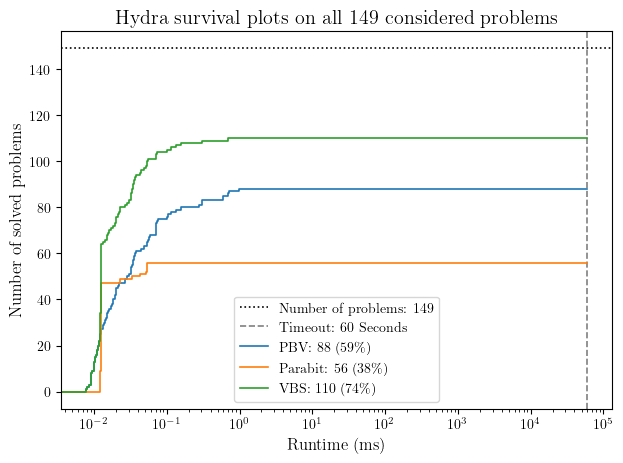

In [3]:

fig, ax = plt.subplots()

data = pd.DataFrame()

data['PBV'] = hydra_pbv['time'].where(hydra_pbv['result'] == 'unsat')
data['Parabit'] = hydra_pb['time_taken'].where(hydra_pb['status'] == 'SUCCESS')
data['VBS'] = data.apply(combine_results, axis=1)
# data['Alive'] = alive_pb['time_taken'].where(alive_pb['status'] == 'SUCCESS')
# data['Rover'] = rover_pb['time_taken'].where(rover_pb['status'] == 'SUCCESS')
# data['Industry'] = cadence_pb['time_taken'].where(cadence_pb['status'] == 'SUCCESS')

plot_cactus(ax, data, 60_000)
ax.legend(loc='best')
ax.set_title(f'Hydra survival plots on all {max(len(hydra_pbv), len(hydra_pb))} considered problems')
plt.tight_layout()
# plt.savefig(f"{FIGURES_PATH}all_problem.pdf")
plt.show()


70
70


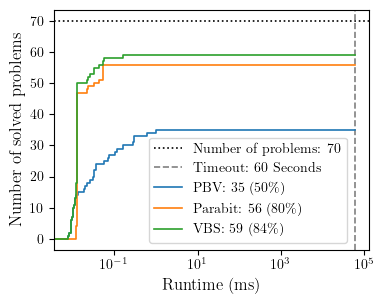

In [4]:
os.makedirs(FIGURES_PATH, exist_ok=True)


fig, ax = plt.subplots(figsize=(4,3.2))

hydra_pbv['file'] = hydra_pbv['file'].map(lambda x: x.replace('.smt2', ''))
hydra_pb['problem_name'] = hydra_pb['problem_name'].map(lambda x: x.replace('hydra_', ''))
in_common = set(hydra_pbv['file']) & set(hydra_pb['problem_name'])
print(len(in_common))
data = pd.DataFrame(index=sorted(in_common))  # Set index to the common problems

# Filter and set index to the file/problem_name, then align with data's index
pbv_filtered = hydra_pbv[hydra_pbv['file'].isin(in_common)].set_index('file')
pb_filtered = hydra_pb[hydra_pb['problem_name'].isin(in_common)].set_index('problem_name')

data['PBV'] = pbv_filtered['time'].where(pbv_filtered['result'] == 'unsat')
data['Parabit'] = pb_filtered['time_taken'].where(pb_filtered['status'] == 'SUCCESS')
data['VBS'] = data.apply(combine_results, axis=1)
print(len(data))  # Now should equal len(in_common)

plot_cactus(ax, data, 60_000)
# plot_survival(ax, data, 60_000)
ax.legend(loc='lower right', bbox_to_anchor=(0.95, 0))
# ax.set_title(f'Hydra survival plots on all {len(in_common)} considered problems')
plt.tight_layout()
# ax.grid(which='both', alpha=0.4, linestyle='dashed')
plt.savefig(FIGURES_PATH / "hydra_cactus.pdf")
plt.show()


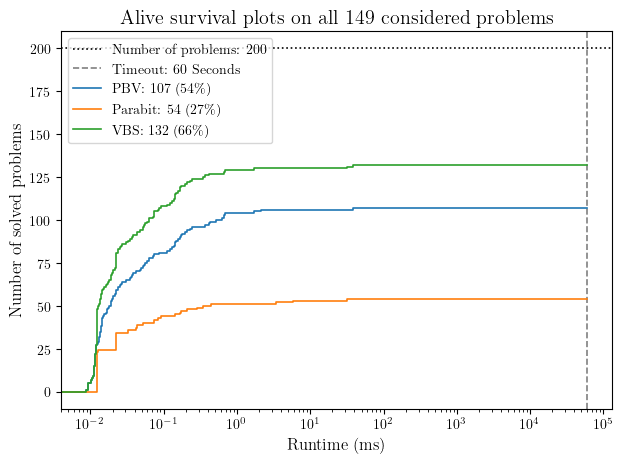

In [5]:

fig, ax = plt.subplots()

data = pd.DataFrame()

data['PBV'] = alive_pbv['time'].where(alive_pbv['result'] == 'unsat')
data['Parabit'] = alive_pb['time_taken'].where(alive_pb['status'] == 'SUCCESS')
data['VBS'] = data.apply(combine_results, axis=1)
# data['Alive'] = alive_pb['time_taken'].where(alive_pb['status'] == 'SUCCESS')
# data['Rover'] = rover_pb['time_taken'].where(rover_pb['status'] == 'SUCCESS')
# data['Industry'] = cadence_pb['time_taken'].where(cadence_pb['status'] == 'SUCCESS')

plot_cactus(ax, data, 60_000)
ax.legend(loc='best')
ax.set_title(f'Alive survival plots on all {max(len(hydra_pbv), len(hydra_pb))} considered problems')
plt.tight_layout()
# plt.savefig(f"{fig_dest}all_problem.pdf")
plt.show()

62
62


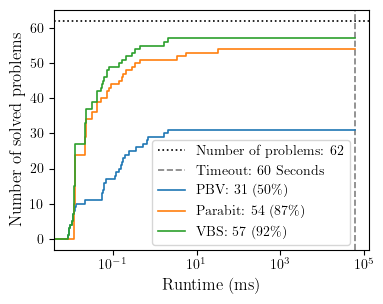

In [6]:

fig, ax = plt.subplots(figsize=(4,3.2))

alive_pbv['file'] = alive_pbv['file'].map(lambda x: x.replace('.smt2', ''))
alive_pb['problem_name'] = alive_pb['problem_name'].map(lambda x: x.replace('hydra_', ''))
in_common = set(alive_pbv['file']) & set(alive_pb['problem_name'])
print(len(in_common))
data = pd.DataFrame(index=sorted(in_common))  # Set index to the common problems

# Filter and set index to the file/problem_name, then align with data's index
pbv_filtered = alive_pbv[alive_pbv['file'].isin(in_common)].set_index('file')
pb_filtered = alive_pb[alive_pb['problem_name'].isin(in_common)].set_index('problem_name')

data['PBV'] = pbv_filtered['time'].where(pbv_filtered['result'] == 'unsat')
data['Parabit'] = pb_filtered['time_taken'].where(pb_filtered['status'] == 'SUCCESS')
data['VBS'] = data.apply(combine_results, axis=1)
print(len(data))  # Now should equal len(in_common)

plot_cactus(ax, data, 60_000)
# plot_survival(ax, data)
ax.legend(loc='lower right', bbox_to_anchor=(0.96, -0.01))
# ax.set_title(f'Alive survival plots on the intersection of {len(in_common)} considered problems')
plt.tight_layout()
# ax.grid(which='both', alpha=0.4, linestyle='dashed')
plt.savefig(FIGURES_PATH / "alive_cactus.pdf")
plt.show()

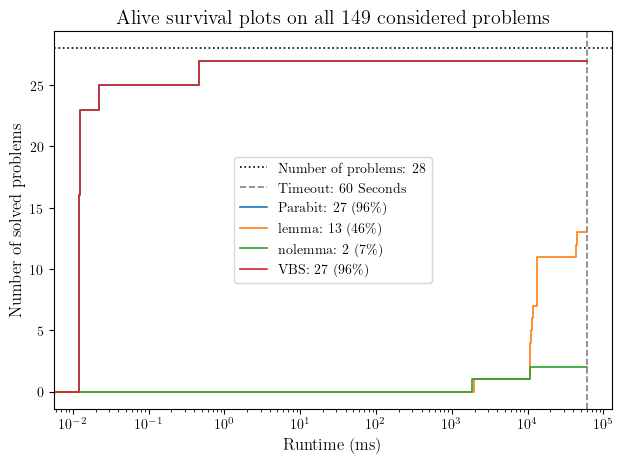

In [7]:
fig, ax = plt.subplots()

data = pd.DataFrame()

data['Parabit'] = rover_pb['time_taken'].where(rover_pb['status'] == 'SUCCESS')
data['lemma'] = (rover_df := rover_mirabelle["lemma"])['time'].where(rover_df['timeout'])
data['nolemma'] = (rover_df := rover_mirabelle["nolemma"])['time'].where(rover_df['timeout'])
data['VBS'] = data.apply(combine_results, axis=1)
# data['Alive'] = alive_pb['time_taken'].where(alive_pb['status'] == 'SUCCESS')
# data['Rover'] = rover_pb['time_taken'].where(rover_pb['status'] == 'SUCCESS')
# data['Industry'] = cadence_pb['time_taken'].where(cadence_pb['status'] == 'SUCCESS')

plot_cactus(ax, data, 60_000)
ax.legend(loc='best')
ax.set_title(f'Alive survival plots on all {max(len(hydra_pbv), len(hydra_pb))} considered problems')
plt.tight_layout()
# plt.savefig(f"{fig_dest}all_problem.pdf")
plt.show()

In [8]:
# Cases that succeeded in rover_mirabelle[lemma] but timed out in rover_pb
mirabelle_lemma = rover_mirabelle["lemma"]

# timeout=True means proof was found (did NOT timeout)
mirabelle_solved = set(mirabelle_lemma[mirabelle_lemma["timeout"]]["name"])

# Strip rover_ prefix from rover_pb problem names to match mirabelle naming
rover_pb_names = rover_pb["problem_name"].map(lambda x: x.replace("rover_", ""))
rover_pb_timed_out = set(rover_pb_names[rover_pb["status"] == "SUCCESS"])

# Intersection: solved by mirabelle lemma but timed out in rover_pb
better_in_mirabelle = mirabelle_solved & rover_pb_timed_out

print(f"Solved in rover_mirabelle[lemma] but timed out in rover_pb ({len(better_in_mirabelle)}):")
for name in sorted(better_in_mirabelle):
    row = mirabelle_lemma[mirabelle_lemma["name"] == name].iloc[0]
    print(f"  {name}  (mirabelle time: {row['time']}ms)")

Solved in rover_mirabelle[lemma] but timed out in rover_pb (13):
  add_assoc_1  (mirabelle time: 13311ms)
  add_assoc_2  (mirabelle time: 13420ms)
  add_assoc_3  (mirabelle time: 13419ms)
  add_assoc_4  (mirabelle time: 13297ms)
  add_zero  (mirabelle time: 11946ms)
  commutativity_add  (mirabelle time: 10852ms)
  commutativity_mult  (mirabelle time: 1993ms)
  mul_one  (mirabelle time: 10836ms)
  mult_assoc_2  (mirabelle time: 43329ms)
  mult_assoc_3  (mirabelle time: 11169ms)
  mult_assoc_4  (mirabelle time: 11374ms)
  mult_sum_same  (mirabelle time: 44764ms)
  sub_to_neg  (mirabelle time: 10851ms)
